# Autoencoder Deep Fusion
Fuses Geneformer (1152) + MethylGPT (128) into a shared 64-dim latent space.
Input:  geneformer_embeddings.npy, methylgpt_embeddings.npy

In [1]:
!pip install umap-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

BASE     = "/content/drive/MyDrive/multiomics-project"
PROC     = f"{BASE}/data/processed"
RESULTS  = f"{BASE}/results/autoencoder"
os.makedirs(RESULTS, exist_ok=True)

GENE_EMB = f"{PROC}/geneformer_embeddings.npy"
METH_EMB = f"{PROC}/methylgpt_embeddings.npy"
LABELS   = f"{PROC}/geneformer_labels.npy"
OUT_EMB  = f"{PROC}/autoencoder_embeddings.npy"

In [4]:
import numpy as np

gene   = np.load(GENE_EMB)
meth   = np.load(METH_EMB)
labels = np.load(LABELS, allow_pickle=True)

print("Geneformer:", gene.shape, gene.dtype)
print("MethylGPT :", meth.shape, meth.dtype)
print("Labels    :", labels.shape, labels.dtype)
print("Rows match:", gene.shape[0] == meth.shape[0] == labels.shape[0])
print("Gene NaN  :", np.isnan(gene).any(), "| Meth NaN:", np.isnan(meth).any())
print("Classes   :", np.unique(labels))
print("Gene range:", gene.min().round(3), "to", gene.max().round(3))
print("Meth range:", meth.min().round(3), "to", meth.max().round(3))

Geneformer: (800, 1152) float32
MethylGPT : (800, 128) float32
Labels    : (800,) object
Rows match: True
Gene NaN  : False | Meth NaN: False
Classes   : ['TCGA-BRCA' 'TCGA-COAD' 'TCGA-KIRC' 'TCGA-LIHC' 'TCGA-LUAD' 'TCGA-THCA']
Gene range: -6.951 to 3.591
Meth range: -0.677 to 0.575


### Normalize each modality
Geneformer (±7) and MethylGPT (±0.6)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

gene_z = StandardScaler().fit_transform(gene)
meth_z = StandardScaler().fit_transform(meth)

X = np.concatenate([gene_z, meth_z], axis=1).astype(np.float32)
print("Fused input:", X.shape)

idx = np.arange(X.shape[0])
tr_idx, va_idx = train_test_split(idx, test_size=0.15, random_state=42, stratify=labels)
print("Train:", len(tr_idx), "| Val:", len(va_idx))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

X_t = torch.tensor(X)
train_dl = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_t[tr_idx]), batch_size=64, shuffle=True)
val_dl = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_t[va_idx]), batch_size=64)

Fused input: (800, 1280)
Train: 680 | Val: 120
Device: cuda


### Defining autoencoder
1280 -> 512 -> 128 -> 64 (latent) -> 128 -> 512 -> 1280

In [6]:
import torch.nn as nn

class FusionAE(nn.Module):
    def __init__(self, in_dim=1280, latent=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 512),    nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = FusionAE().to(device)
print(model)

FusionAE(
  (encoder): Sequential(
    (0): Linear(in_features=1280, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=512, out_features=1

### Train

In [7]:
import copy

opt     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
EPOCHS, patience = 300, 25
best_val, best_state, wait = float("inf"), None, 0

for epoch in range(1, EPOCHS + 1):
    model.train(); tr = 0.0
    for (xb,) in train_dl:
        xb = xb.to(device)
        opt.zero_grad()
        recon, _ = model(xb)
        loss = loss_fn(recon, xb)
        loss.backward(); opt.step()
        tr += loss.item() * xb.size(0)
    tr /= len(tr_idx)

    model.eval(); va = 0.0
    with torch.no_grad():
        for (xb,) in val_dl:
            xb = xb.to(device)
            recon, _ = model(xb)
            va += loss_fn(recon, xb).item() * xb.size(0)
    va /= len(va_idx)

    if va < best_val:
        best_val, best_state, wait = va, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train {tr:.4f} | val {va:.4f} | best {best_val:.4f}")
    if wait >= patience:
        print(f"Early stop at epoch {epoch}"); break

model.load_state_dict(best_state)
print("Best val MSE:", round(best_val, 4))

Epoch   1 | train 0.8449 | val 0.5990 | best 0.5990
Epoch  10 | train 0.3318 | val 0.2761 | best 0.2761
Epoch  20 | train 0.2936 | val 0.2397 | best 0.2397
Epoch  30 | train 0.2627 | val 0.2230 | best 0.2230
Epoch  40 | train 0.2472 | val 0.2095 | best 0.2078
Epoch  50 | train 0.2375 | val 0.2014 | best 0.2007
Epoch  60 | train 0.2305 | val 0.1945 | best 0.1937
Epoch  70 | train 0.2211 | val 0.1884 | best 0.1884
Epoch  80 | train 0.2122 | val 0.1863 | best 0.1848
Epoch  90 | train 0.2094 | val 0.1830 | best 0.1830
Epoch 100 | train 0.2120 | val 0.1829 | best 0.1805
Epoch 110 | train 0.1982 | val 0.1799 | best 0.1798
Epoch 120 | train 0.2054 | val 0.1808 | best 0.1786
Epoch 130 | train 0.1988 | val 0.1771 | best 0.1771
Epoch 140 | train 0.1916 | val 0.1758 | best 0.1744
Epoch 150 | train 0.1840 | val 0.1752 | best 0.1744
Epoch 160 | train 0.1876 | val 0.1733 | best 0.1733
Epoch 170 | train 0.1848 | val 0.1733 | best 0.1729
Epoch 180 | train 0.1830 | val 0.1745 | best 0.1718
Epoch 190 | 

### What the training shows

The model trained fine. The reconstruction loss started at 0.84 and dropped
down to about 0.167, then stopped improving, so it learned what it could.

The training loss and validation loss stayed close to each other the whole time
(0.167 vs 0.168 at the end). If the model was just
memorizing the training data, the training loss would be much lower than the
validation loss. Here they're basically equal, so it's not overfitting.

Since I normalized every feature first (so each one has variance 1), a loss of
0.166 means the model only "misses" about 17% of the data when it rebuilds it.
So the 64 numbers it learned hold around 83% of the information from the original
1280 (RNA + methylation combined). That's a good result - it shrinks the data 20x
but keeps most of the signal. This is the shared latent representation.

In [8]:
model.eval()
with torch.no_grad():
    Z = model.encoder(X_t.to(device)).cpu().numpy()

print("Latent:", Z.shape, "| NaN:", np.isnan(Z).any())
np.save(OUT_EMB, Z)
print("Saved ->", OUT_EMB)

Latent: (800, 64) | NaN: False
Saved -> /content/drive/MyDrive/multiomics-project/data/processed/autoencoder_embeddings.npy


### UMAP of the fused latent, colored by cancer type

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


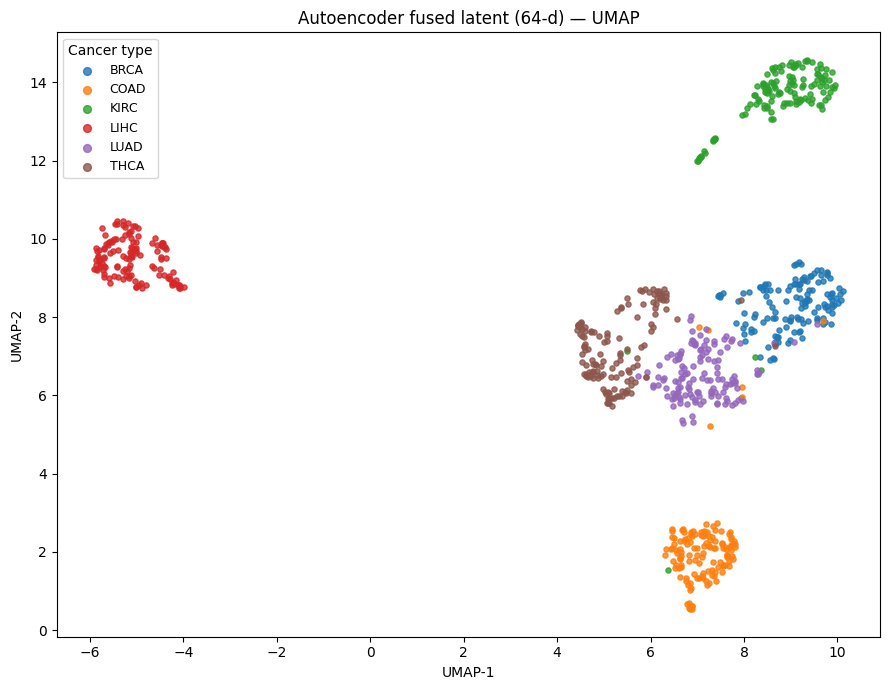

Saved -> /content/drive/MyDrive/multiomics-project/results/autoencoder/umap_autoencoder.png


In [9]:
import umap, matplotlib.pyplot as plt

emb2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(Z)

plt.figure(figsize=(9, 7))
for c in np.unique(labels):
    m = labels == c
    plt.scatter(emb2d[m, 0], emb2d[m, 1], s=14, alpha=0.8, label=c.replace("TCGA-", ""))
plt.legend(title="Cancer type", markerscale=1.5, fontsize=9)
plt.title("Autoencoder fused latent (64-d) — UMAP")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.tight_layout()

umap_path = f"{RESULTS}/umap_autoencoder.png"
plt.savefig(umap_path, dpi=150); plt.show()
print("Saved ->", umap_path)

UMAP of the 64-dimensional autoencoder-fused embedding, colored by cancer type.
The model was trained unsupervised (no labels), yet patients cluster by cancer
type - LIHC, KIRC and COAD form fully separated clusters, while BRCA, LUAD and
THCA form distinct but adjacent groups. This shows the deep-fusion latent space
captures cancer-type-specific biological signal.

### Metrics

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import silhouette_score
import json

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(LogisticRegression(max_iter=2000), Z, labels, cv=cv, scoring="accuracy")
f1  = cross_val_score(LogisticRegression(max_iter=2000), Z, labels, cv=cv, scoring="f1_macro")
sil = silhouette_score(Z, labels)

metrics = {
    "latent_dim": int(Z.shape[1]),
    "n_samples": int(Z.shape[0]),
    "recon_val_mse": round(float(best_val), 4),
    "cv_accuracy_mean": round(float(acc.mean()), 4),
    "cv_accuracy_std":  round(float(acc.std()), 4),
    "cv_f1_macro_mean": round(float(f1.mean()), 4),
    "silhouette": round(float(sil), 4),
}
print(json.dumps(metrics, indent=2))

with open(f"{RESULTS}/metrics_autoencoder.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved ->", f"{RESULTS}/metrics_autoencoder.json")

{
  "latent_dim": 64,
  "n_samples": 800,
  "recon_val_mse": 0.1666,
  "cv_accuracy_mean": 0.9837,
  "cv_accuracy_std": 0.0064,
  "cv_f1_macro_mean": 0.9837,
  "silhouette": 0.0702
}
Saved -> /content/drive/MyDrive/multiomics-project/results/autoencoder/metrics_autoencoder.json


### Conclusion

To check if the 64 fused numbers are actually useful, I trained a logistic
regression classifier on them (5-fold cross-validation) to predict cancer type:

- Accuracy: 0.984
- Macro-F1: 0.984
- Silhouette: 0.07

The classifier gets 98.4% accuracy, and the macro-F1 is just as high, which means
every cancer type is predicted well, not only the common ones. So the fused
embedding clearly keeps the biological differences between the cancer types, and
it's a strong input for the final classifier.

The silhouette score is low (0.07), but this is expected and doesn't contradict
the high accuracy. Silhouette measures how much space is between clusters, and in
the UMAP some types (BRCA, LUAD, THCA) sit close together. The classifier can
still separate them with a decision boundary even when they are close, so
accuracy and F1 are the more meaningful metrics here.